In [19]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

In [20]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Rice"
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
num_class = 4
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 2791 files belonging to 4 classes.
Using 2233 files for training.
Found 2791 files belonging to 4 classes.
Using 558 files for validation.
Training dataset size: 70 batches
Validation dataset size: 9 batches
Test dataset size: 9 batches


In [21]:
class_names = train_dataset.class_names
class_names

['Rice___Brown_Spot', 'Rice___Healthy', 'Rice___Hispa', 'Rice___Leaf_Blast']

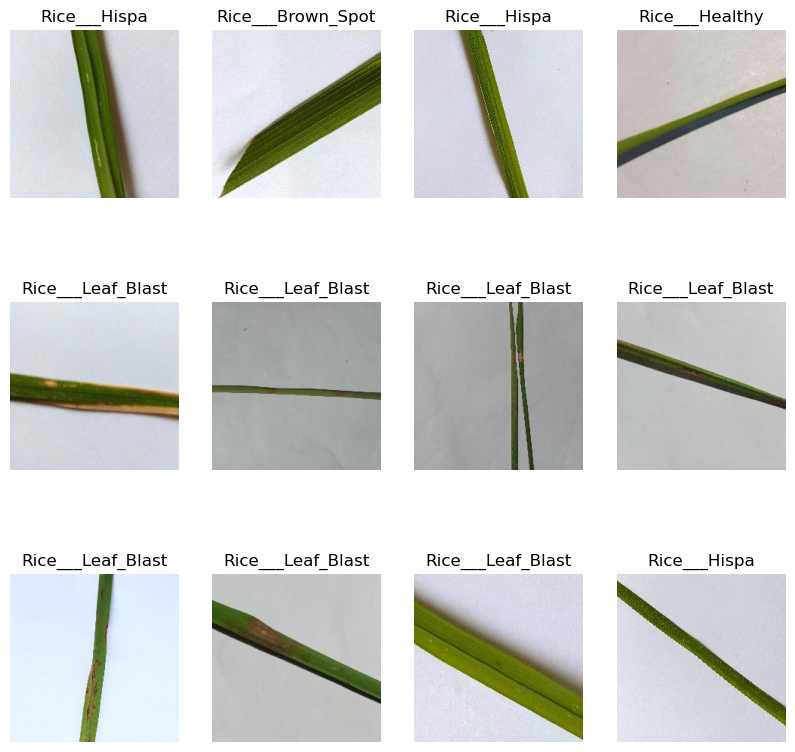

In [22]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

C:\Users\NAHID\AppData\Local\Temp\ipykernel_13556\2436110488.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")


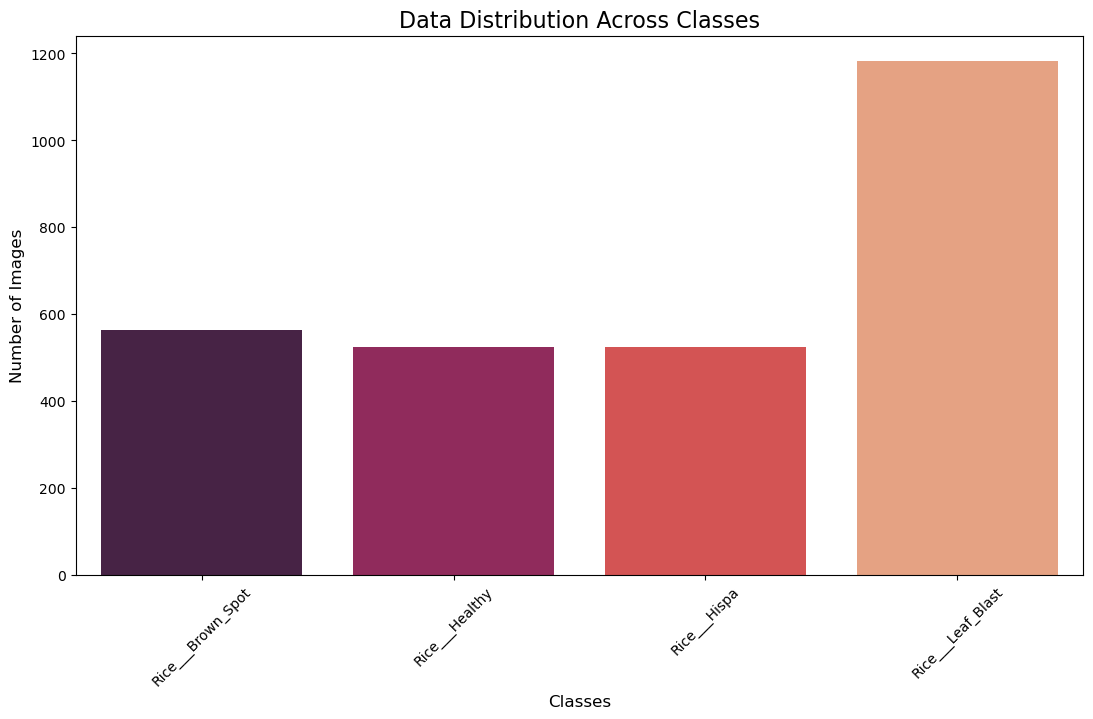

In [23]:
Data_imbalance = []
folder_names = []

# Iterate through each folder in the directory
for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        files = gb.glob(pathname=str(folder_path + "/*.*"))
        Data_imbalance.append(len(files))
        folder_names.append(folder)  # Collect folder names dynamically

# Plot the barplot with dynamic names
plt.figure(figsize=(13, 7))
sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")
plt.title("Data Distribution Across Classes", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if they are long
plt.show()

In [24]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 1.24
Weight for class 1: 1.33
Weight for class 2: 1.33
Weight for class 3: 0.59


In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [26]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

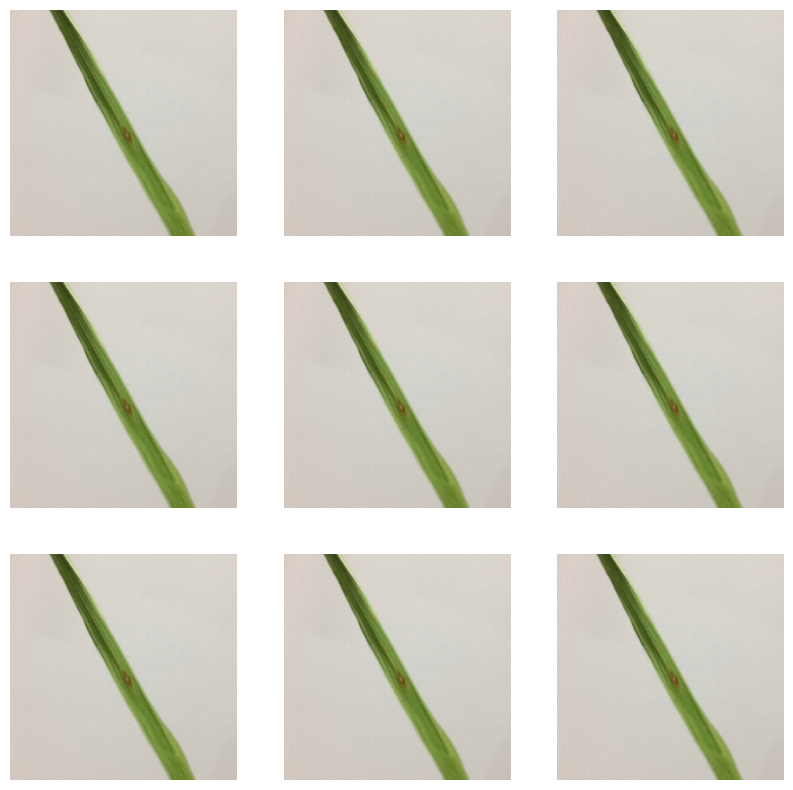

In [27]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

In [28]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

In [29]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Define SAM training step with tunable rho (same as before)
def train_step_sam(model, data, rho=0.05):
    if len(data) == 3:
        x, y, sample_weight = data
    else:
        x, y = data
        sample_weight = None

    # First forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred, 
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    trainable_vars = model.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    
    # Calculate perturbation
    grad_norm = tf.linalg.global_norm(gradients)
    eps_w = [tf.math.multiply(g, rho / grad_norm) for g in gradients]
    
    # Apply perturbation
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_add(eps)
    
    # Second forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred,
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    gradients = tape.gradient(loss, trainable_vars)
    
    # Remove perturbation and apply gradients
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_sub(eps)
    
    model.optimizer.apply_gradients(zip(gradients, trainable_vars))
    
    # Update metrics
    model.compiled_metrics.update_state(y, y_pred, sample_weight=sample_weight)
    return {m.name: m.result() for m in model.metrics}

# Define custom DenseNet model with SAM
class MyDenseNet(tf.keras.Model):
    def __init__(self, densenet_base, data_augmentation, num_classes, rho):
        super(MyDenseNet, self).__init__(name='DenseNet')
        self.data_augmentation = data_augmentation
        self.densenet_base = densenet_base
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.dense1 = layers.Dense(128, activation='relu')
        self.dropout = layers.Dropout(0.5)
        self.dense2 = layers.Dense(num_classes, activation='softmax')
        self.rho = rho

    def call(self, x):
        x = self.data_augmentation(x)
        x = self.densenet_base(x)
        x = self.global_avg_pool(x)
        x = self.dense1(x)
        x = self.dropout(x)
        return self.dense2(x)

    def train_step(self, data):
        return train_step_sam(self, data, rho=self.rho)

# Define the model building function for Keras Tuner
def build_model(hp):
    rho = hp.Float('rho', min_value=0.01, max_value=0.1, step=0.01)
    
    # Create DenseNet201 base model (frozen)
    densenet_base = tf.keras.applications.DenseNet201(
        weights='imagenet',
        input_shape=IMG_SIZE + (3,),
        include_top=False
    )
    densenet_base.trainable = False
    
    model = MyDenseNet(densenet_base, data_augmentation, 4, rho)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Instantiate the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='my_dir',
    project_name='densenet_sam_rho_tuning'
)

# Display search space summary
tuner.search_space_summary()

# Perform the hyperparameter search
tuner.search(train_dataset, 
             validation_data=validation_dataset, 
             epochs=5,
             class_weight=class_weight)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best rho: {best_hps.get('rho')}")

# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
best_history = best_model.fit(train_dataset,
               validation_data=validation_dataset,
               epochs=10,
               class_weight=class_weight)

Search space summary
Default search space size: 1
rho (Float)
{'default': 0.01, 'conditions': [], 'min_value': 0.01, 'max_value': 0.1, 'step': 0.01, 'sampling': None}
Best rho: 0.01
Epoch 1/10
70/70 [==============================] - 94s 961ms/step - loss: 1.1551 - accuracy: 0.5002 - val_loss: 0.9331 - val_accuracy: 0.6042
Epoch 2/10
70/70 [==============================] - 89s 1s/step - loss: 0.9367 - accuracy: 0.6095 - val_loss: 0.7390 - val_accuracy: 0.7118
Epoch 3/10
70/70 [==============================] - 78s 989ms/step - loss: 0.8980 - accuracy: 0.6167 - val_loss: 0.7684 - val_accuracy: 0.6910
Epoch 4/10
70/70 [==============================] - 36s 483ms/step - loss: 0.8720 - accuracy: 0.6485 - val_loss: 0.8285 - val_accuracy: 0.6562
Epoch 5/10
70/70 [==============================] - 35s 476ms/step - loss: 0.8590 - accuracy: 0.6458 - val_loss: 0.6839 - val_accuracy: 0.7014
Epoch 6/10
70/70 [==============================] - 34s 466ms/step - loss: 0.8187 - accuracy: 0.6552 - val

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [31]:
print(f"Test dataset type: {type(test_dataset)}")  

for image, label in test_dataset.take(1):
    print(f"Sample image shape: {image.shape}, Sample label shape: {label.shape}")

# Initialize empty lists to store true labels and predicted labels
y_true = []
y_pred_classes = []

# Iterate through the test dataset to collect the true labels and predictions
for images, labels in test_dataset:
    # Collect true labels (convert to numpy array)
    y_true.extend(labels.numpy())
    
    # Make predictions using the model
    y_pred_prob = best_model(images, training=False)  # Model predictions (probabilities)
    
    # Convert predicted probabilities to class labels (argmax along the class axis)
    y_pred_classes.extend(tf.argmax(y_pred_prob, axis=1).numpy())

# Convert y_true and y_pred_classes to NumPy arrays for compatibility with sklearn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Ensure the shape of the true and predicted labels are consistent
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred_classes: {y_pred_classes.shape}")

# Now, you can compute the precision, recall, and f1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Test dataset type: <class 'tensorflow.python.data.ops.dataset_ops.ParallelMapDataset'>
Sample image shape: (32, 224, 224, 3), Sample label shape: (32,)
Shape of y_true: (270,)
Shape of y_pred_classes: (270,)
9/9 [==============================] - 5s 116ms/step - loss: 0.6692 - accuracy: 0.6889
Test Loss: 0.6691657304763794
Test Accuracy: 0.6888889074325562
Precision: 0.7336463844797178
Recall: 0.6703703703703704
F1-Score: 0.6792859963426408


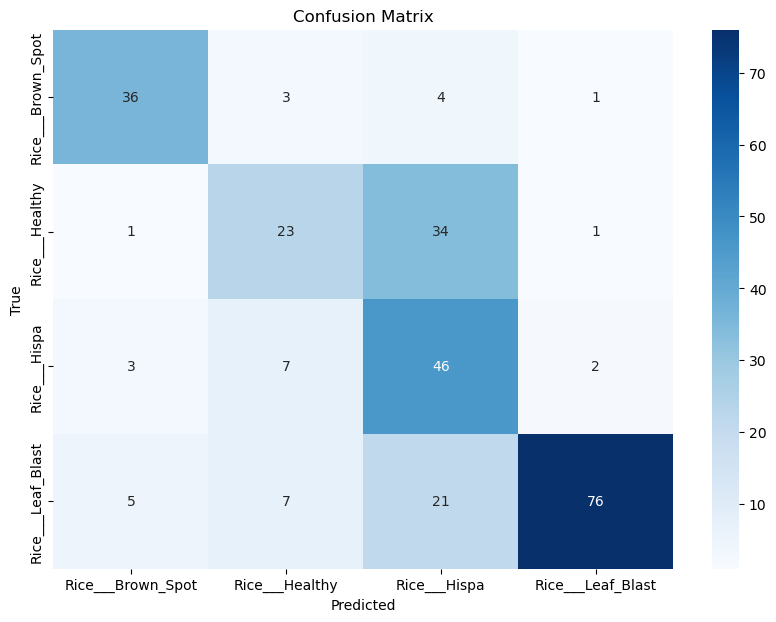

In [32]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

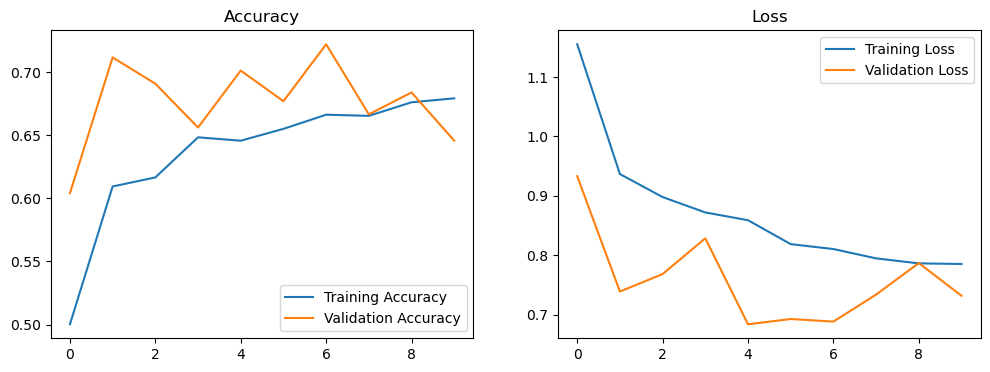

In [33]:
#Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [34]:
best_model.save("rice_densenet_sam_model", save_format="tf")